# 2.5 Orthogonal Bases in Function Space

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter II — Orthogonality and Least Squares",
    number="2.5",
    title="Orthogonal Bases in Function Space",
    blurb="Everything in this chapter was about vectors, and none of it needed "
    "them to be lists of numbers — run Gram–Schmidt on the monomials and out "
    "come the Legendre polynomials, with a Gram matrix whose condition number "
    "is exactly 2d+1 where the obvious basis reaches 10^17.",
    difficulty="advanced",
    estimate="105–135 min",
)

<ECP header: 2613 chars of HTML>

## Notebook overview

Nothing in this chapter used the fact that a vector is a list of numbers. A
projection needs an inner product; Gram–Schmidt needs an inner product; least
squares needs an inner product. Supply one on a space of *functions* and the
entire apparatus transfers without a single change of argument. That is the
payoff of [§1.5](../01-matrices/vector-spaces-coordinates.ipynb)'s insistence
that a vector space is defined by its axioms rather than by $\mathbb{R}^n$.

The inner product is $\langle f, g\rangle = \int_{-1}^{1} f(x)g(x)\,dx$, and the
consequences are immediate and concrete. Running Gram–Schmidt on the monomials
$\{1, x, x^2, \dots\}$ produces the **Legendre polynomials** — not something
resembling them, but them exactly, to $3\times10^{-13}$ against
`scipy.special.legendre`. The Chebyshev polynomials come out of a different
weight, and the discrete Fourier transform out of a different space entirely,
and all three are the same construction wearing different coats.

The practical half is a conditioning story, and it is sharper here than
anywhere else in the chapter. The monomials are a *terrible* basis: their Gram
matrix is a Hilbert-like matrix whose condition number reaches $10^{17}$ by
degree 30, and a least-squares fit in that basis stops converging around degree
22 — the error gets *worse* as more terms are added. The Legendre Gram matrix
is diagonal, so its condition number is exactly $2d+1$, and the same fit keeps
improving. Same subspace, same best approximation, same answer in exact
arithmetic; a factor of $10^{16}$ in how hard it is to compute.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Trefethen's *Approximation Theory and Approximation Practice*
> {cite}`trefethen2005spectra` is the modern companion for the Chebyshev
> material; Golub and Van Loan {cite}`golub2013` §5.3 for the conditioning;
> Boyd and Vandenberghe {cite}`boyd2018` Chapter 13 for the least-squares view.

## Theory in brief

### An inner product on functions

On $C[-1,1]$, define

```{math}
:label: eq-fbasis-inner
\langle f, g\rangle = \int_{-1}^{1} f(x)\,g(x)\,dx ,
\qquad \|f\| = \sqrt{\langle f, f\rangle} .
```

This satisfies every axiom [§0.3](../00-machine/vectors-norms-inner-products.ipynb)
required — symmetry, bilinearity, and positive definiteness — so Cauchy–Schwarz,
the triangle inequality, Pythagoras, orthogonal projection and Gram–Schmidt all
hold verbatim. "Orthogonal" now means $\int_{-1}^{1} fg = 0$, which is a
statement about cancellation rather than about angles, but it is the same
statement.

### Computing the inner product exactly

The integral is evaluated by **Gauss–Legendre quadrature**: `leggauss(n)` returns
nodes $x_i$ and weights $w_i$ with

```{math}
:label: eq-fbasis-quad
\int_{-1}^{1} p(x)\,dx = \sum_{i=1}^{n} w_i\,p(x_i)
\qquad\text{exactly, for every polynomial } p \text{ of degree} \le 2n-1 .
```

The $2n-1$ is sharp and it is the reason the rule exists: $n$ nodes and $n$
weights are $2n$ free parameters, and the rule spends all of them. For
polynomial work this makes {eq}`eq-fbasis-inner` an *exact* computation rather
than an approximation, which matters when the identities below are checked to
$10^{-14}$.

### Gram–Schmidt, unchanged

Applied to $\{1, x, x^2, \dots, x^d\}$, the recurrence is the one from
[§2.2](gram-schmidt-qr.ipynb) with the new inner product substituted:

```{math}
:label: eq-fbasis-gs
q_k = x^k - \sum_{j<k}
  \frac{\langle x^k, q_j\rangle}{\langle q_j, q_j\rangle}\, q_j .
```

Normalising each $q_k$ so that $q_k(1) = 1$ gives the **Legendre polynomials**
$P_k$, which satisfy

```{math}
:label: eq-fbasis-legendre-gram
\langle P_j, P_k\rangle = \frac{2}{2k+1}\,\delta_{jk} .
```

### Coefficients are inner products

Once a basis is orthogonal, the expansion coefficients require no linear solve:

```{math}
:label: eq-fbasis-coeffs
f \approx \sum_{k=0}^{d} c_k P_k ,
\qquad c_k = \frac{\langle f, P_k\rangle}{\langle P_k, P_k\rangle} ,
```

and these $c_k$ are exactly the least-squares coefficients — the Gram matrix is
diagonal, so the normal equations decouple into $d+1$ scalar divisions. This is
the payoff of orthogonality, and it is the same payoff $QR$ delivered in
[§2.3](least-squares-four-ways.ipynb).

### Why the monomials are a bad basis

In the monomial basis the Gram matrix is not diagonal but

```{math}
:label: eq-fbasis-monogram
G_{ij} = \int_{-1}^{1} x^{i+j}\,dx =
\begin{cases} \dfrac{2}{i+j+1}, & i+j \text{ even},\\[4pt] 0, & i+j \text{ odd},\end{cases}
```

a near-relative of the Hilbert matrix of
[§0.2](../00-machine/floating-point.ipynb), with the same exponential growth in
$\kappa$. The subspace spanned is identical and so is the best approximation in
it; only the *coordinates* differ, and by
[§1.5](../01-matrices/vector-spaces-coordinates.ipynb) a change of basis can
change the conditioning of everything without changing the answer.

### Chebyshev, and orthogonality on a grid

With the weight $1/\sqrt{1-x^2}$ the same construction yields the **Chebyshev
polynomials**, which have the closed form

```{math}
:label: eq-fbasis-cheb
T_k(x) = \cos\!\left(k\arccos x\right) ,
```

and a second, discrete orthogonality: evaluated at the $N$ Chebyshev–Gauss
nodes $x_i = \cos\!\big((2i+1)\pi/2N\big)$, the vectors
$\big(T_j(x_0), \dots, T_j(x_{N-1})\big)$ are *exactly* orthogonal, with squared
length $N$ for $j = 0$ and $N/2$ otherwise. Continuous orthogonality has become
matrix orthogonality, with no approximation anywhere.

### The DFT is the same idea on $\mathbb{C}^n$

Take the space $\mathbb{C}^n$ with $\langle x, y\rangle = \bar{x}^{\top}y$ and
the basis of sampled complex exponentials. The matrix is

```{math}
:label: eq-fbasis-dft
F_{jk} = \omega^{jk}, \quad \omega = e^{-2\pi i/n},
\qquad F^{*}F = n I ,
```

so $F/\sqrt{n}$ is **unitary**: the DFT is a change to an orthonormal basis and
nothing more. Unitarity gives **Parseval**,

```{math}
:label: eq-fbasis-parseval
\|F\mathbf{v}\|_2^2 = n\,\|\mathbf{v}\|_2^2 ,
```

the statement that changing to an orthonormal basis preserves length, which is
the same reason $QR$ was stable in [§2.2](gram-schmidt-qr.ipynb).

### Gibbs

Orthogonal expansions converge in $\|\cdot\|_2$, and that is weaker than it
sounds. At a jump discontinuity the partial sums overshoot by a fixed
proportion of the jump,

```{math}
:label: eq-fbasis-gibbs
\lim_{M\to\infty} \frac{\text{overshoot}}{\text{jump}}
= \frac{1}{\pi}\int_0^{\pi}\frac{\sin t}{t}\,dt - \frac{1}{2}
= 0.0894898\ldots ,
```

and this does **not** shrink as more terms are added. The overshoot narrows, so
its contribution to the $L^2$ error goes to zero, but its height converges to
$8.949\%$ of the jump and stays there.

---
## Setup

Data only: the quadrature nodes and weights, and reference Legendre values
from scipy. The exact inner product — the notebook's instrument — is built
and certified in Exercise 1, which is titled after it.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from numpy.polynomial.legendre import leggauss
from scipy.special import legendre
from scipy.fft import dct

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps
np.set_printoptions(precision=5, suppress=False, linewidth=110)

# One high-order rule, reused throughout: exact for every polynomial of degree
# <= 79, which covers every polynomial identity checked below.
NQ = 40
XQ, WQ = leggauss(NQ)



# data: reference values — scipy's Legendre polynomials, the answer key the
# exercises check their own constructions against.
def P_scipy(k, x=XQ):
    """Values of the degree-k Legendre polynomial at x, from scipy.special.

    ``scipy.special.legendre`` returns coefficients highest-power-first, which is
    the opposite of ``numpy.polynomial``'s convention; the reversal here is the
    only place that difference is handled.
    """
    return Polynomial(np.asarray(legendre(k))[::-1])(x)

## Exercise 1: The instrument: an inner product that is exact

Before any identity can be checked to $10^{-14}$, the thing doing the checking
has to be exact. Gauss–Legendre quadrature {eq}`eq-fbasis-quad` is, on
polynomials, and the boundary at degree $2n-1$ is not a rule of thumb but a
theorem with a sharp edge: at degree $2n$ the rule fails, and it fails by a
visible amount rather than by rounding.

**Part a)** Take `x, w = np.polynomial.legendre.leggauss(8)` and evaluate
$\int_{-1}^{1} x^d\,dx$ as `np.sum(w * x**d)` for $d = 14, 15, 16, 17$. Compare
against the exact value, which is $0$ for odd $d$ and $2/(d+1)$ for even $d$.

**Part b)** Confirm the sharpness. The rule is exact to $10^{-14}$ at
$d = 14$ and $d = 15 = 2n-1$, and wrong by $4.7\times10^{-5}$ at
$d = 16 = 2n$ — an error five orders above rounding, so the failure is
structural rather than numerical. Report the error at each degree and confirm
the jump.

**Part c)** Verify the axioms of {eq}`eq-fbasis-inner` numerically on the
40-point rule. Write `inner(u, v)` — the weighted sum of
{eq}`eq-fbasis-inner` over the 40-point nodes — and verify with it, on the
sampled functions $u = x^3 - x$,
$v = x^2 + 1$, $s = e^{x}$. Confirm symmetry $\langle u,v\rangle =
\langle v,u\rangle$ to $10^{-15}$, bilinearity
$\langle u + 2s, v\rangle = \langle u,v\rangle + 2\langle s,v\rangle$ to
$10^{-14}$, and positive definiteness $\langle u,u\rangle > 0$ with
$\langle 0,0\rangle = 0$.

**Part d)** Confirm Cauchy–Schwarz, which now reads
$\left|\int uv\right| \le \|u\|\,\|v\|$, on the three pairs drawn from
$\{u, v, s\}$, and report the ratio $|\langle u,v\rangle|/(\|u\|\|v\|)$ for
each — the cosine of an angle between two functions.

In [3]:
# (solution hidden on the public site)


Gauss-Legendre with n = 8: exact through degree 15

   d       quadrature            exact        error
  14     0.1333333333     0.1333333333    8.049e-16
  15     0.0000000000     0.0000000000    0.000e+00
  16     0.1176005105     0.1176470588    4.655e-05
  17     0.0000000000     0.0000000000    0.000e+00

error jumps by a factor of 5.8e+10 between degree 15 = 2n-1 and degree 16 = 2n

the axioms of Eq. 1, on u = x^3 - x, v = x^2 + 1, s = exp(x):
  symmetry       |<u,v> - <v,u>|            = 1.279e-17
  bilinearity    |<u+2s,v> - <u,v> - 2<s,v>| = 8.882e-16
  positivity     <u,u> = 0.1523809524 > 0, <0,0> = 0.0e+00

Cauchy-Schwarz, |<f,g>| <= |f| |g|:
  u, v: |<f,g>| =  0.000000 <=  0.754247 = |f||g|   cos = 0.000000
  u, s: |<f,g>| =  0.286251 <=  0.743414 = |f||g|   cos = 0.385050
  v, s: |<f,g>| =  3.229287 <=  3.679712 = |f||g|   cos = 0.877592


### Validation 1

The quadrature check is two-sided on purpose: exactness at $2n-1$ says the rule
works, and failure at $2n$ says the bound is the true one and not a
conservative estimate. Everything later in the notebook rests on the first
half, so it is worth establishing that the instrument is exact before trusting
a $10^{-14}$ agreement.

In [4]:
validate.check(
    quad_err[14] < 1e-14 and quad_err[15] < 1e-14,
    "Gauss-Legendre with 8 nodes is exact through degree 2n-1 = 15 (Eq. 2)",
    f"error {quad_err[14]:.2e} at degree 14 and {quad_err[15]:.2e} at degree 15",
)
validate.check(
    quad_err[16] > 1e-6,
    "and the bound is sharp: it fails at degree 2n = 16",
    f"error {quad_err[16]:.3e}, five orders above rounding, so the failure is "
    "structural — n nodes and n weights are 2n parameters and the rule has "
    "spent them all",
)
validate.check(
    sym < 1e-15 and bilin < 1e-14 and inner(u, u) > 0,
    "the L2 inner product satisfies the axioms of Eq. 1",
    f"symmetry {sym:.2e}, bilinearity {bilin:.2e}, <u,u> = {inner(u,u):.6f} > 0",
)
validate.check(
    all(r <= 1.0 + 1e-14 for r in cs_ratios),
    "and Cauchy-Schwarz holds for functions exactly as it did for vectors",
    f"cosines {[f'{r:.4f}' for r in cs_ratios]}, all at most 1",
)

✓  Gauss-Legendre with 8 nodes is exact through degree 2n-1 = 15 (Eq. 2)   [error 8.05e-16 at degree 14 and 0.00e+00 at degree 15]
✓  and the bound is sharp: it fails at degree 2n = 16   [error 4.655e-05, five orders above rounding, so the failure is structural — n nodes and n weights are 2n parameters and the rule has spent them all]
✓  the L2 inner product satisfies the axioms of Eq. 1   [symmetry 1.28e-17, bilinearity 8.88e-16, <u,u> = 0.152381 > 0]
✓  and Cauchy-Schwarz holds for functions exactly as it did for vectors   [cosines ['0.0000', '0.3850', '0.8776'], all at most 1]


True

## Exercise 2: Gram–Schmidt on the monomials produces the Legendre polynomials

{eq}`eq-fbasis-gs` is [§2.2](gram-schmidt-qr.ipynb)'s recurrence with one
substitution: the dot product becomes the integral. Nothing else changes, and
the result is not merely *an* orthogonal basis of polynomials but, after the
normalisation $q_k(1) = 1$, the classical Legendre polynomials — the same ones
that appear in the multipole expansion, in spherical harmonics, and in the
quadrature rule being used to compute them. That last point is worth noticing:
the nodes of `leggauss(n)` are the roots of $P_n$, so this exercise computes
the Legendre polynomials with a rule built out of the Legendre polynomials.

**Part a)** Write `gram_schmidt_L2(d)` returning a list of `d + 1`
`numpy.polynomial.Polynomial` objects, the Gram–Schmidt output for
$\{1, x, \dots, x^d\}$ under {eq}`eq-fbasis-inner`. Work in *coefficient*
arrays: start each step from the unit coefficient vector `c` with `c[k] = 1`,
and for each earlier polynomial `p_j` subtract
`(inner(p_k(XQ), p_j(XQ)) / inner(p_j(XQ), p_j(XQ))) * c_j` from `c`, exactly
as {eq}`eq-fbasis-gs` prescribes. Use $d = 5$.

**Write this one yourself** — the implementation is the lesson.

**Part b)** Normalise. Divide each output polynomial by its value at $x = 1$,
evaluated as `p(1.0)`, to fix the classical convention $P_k(1) = 1$. Print the
coefficient arrays.

**Part c)** Confirm orthogonality by building the $6\times6$ Gram matrix
$G_{jk} = \langle P_j, P_k\rangle$ with `inner`, and report the largest
off-diagonal entry in absolute value, which comes out $4\times10^{-16}$.

**Part d)** Confirm the closed form {eq}`eq-fbasis-legendre-gram`: the diagonal
should be $2, \tfrac{2}{3}, \tfrac{2}{5}, \tfrac{2}{7}, \tfrac{2}{9},
\tfrac{2}{11}$, that is $2/(2k+1)$. Report the largest deviation, which is
$1.8\times10^{-14}$.

**Part e)** Confirm these are the Legendre polynomials and not merely
Legendre-like, by comparing the coefficient arrays against
`np.asarray(scipy.special.legendre(k))[::-1]` (scipy orders coefficients
highest-power-first, `numpy.polynomial` lowest-first, hence the reversal).
Report the largest coefficient difference for each $k$; the worst is
$3.5\times10^{-13}$ at $k = 5$, with the error growing with degree because
each Gram–Schmidt step inherits the errors of all the previous ones — the same
accumulation [§2.2](gram-schmidt-qr.ipynb) measured.

**Part f)** Plot $P_0$ through $P_5$ on $[-1,1]$, and confirm from the plot and
from `p(1.0)` that every one passes through $(1, 1)$.

In [5]:
# (solution hidden on the public site)


Gram-Schmidt output, normalised so that P_k(1) = 1:
  P_0: [1. 0. 0. 0. 0. 0.]
  P_1: [-0.  1.  0.  0.  0.  0.]
  P_2: [-0.5  0.   1.5  0.   0.   0. ]
  P_3: [ 0.  -1.5  0.   2.5  0.   0. ]
  P_4: [ 0.375 -0.    -3.75   0.     4.375  0.   ]
  P_5: [ 0.     1.875 -0.    -8.75   0.     7.875]

Gram matrix G[j,k] = <P_j, P_k>:
  largest off-diagonal entry : 4.441e-16
  diagonal                   : [2.      0.66667 0.4     0.28571 0.22222 0.18182]
  predicted 2/(2k+1)         : [2.      0.66667 0.4     0.28571 0.22222 0.18182]
  largest deviation          : 1.743e-14

against scipy.special.legendre, coefficient by coefficient:
  k = 0: max |coefficient difference| = 0.000e+00
  k = 1: max |coefficient difference| = 2.168e-18
  k = 2: max |coefficient difference| = 5.329e-15
  k = 3: max |coefficient difference| = 2.487e-14
  k = 4: max |coefficient difference| = 9.592e-14
  k = 5: max |coefficient difference| = 3.340e-13
  the error grows with k: each step inherits every earlier step's err

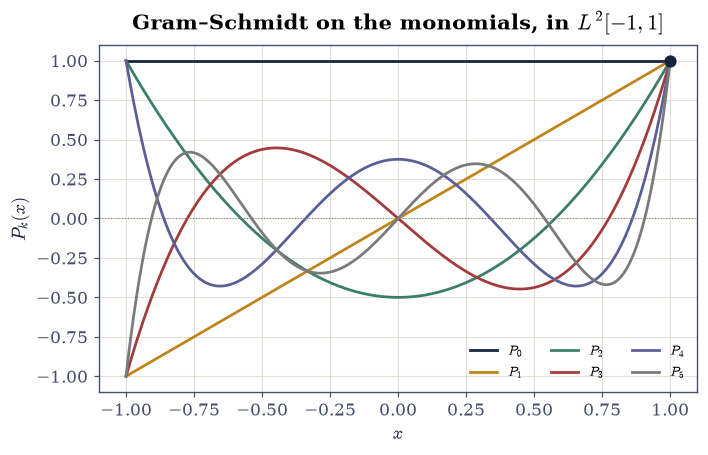

In [6]:
# (solution hidden on the public site)


### Validation 2

Orthogonality alone would be satisfied by infinitely many bases, so the check
that matters is the closed form {eq}`eq-fbasis-legendre-gram` together with the
coefficient comparison: the first says the construction produced the right
*inner products*, the second that it produced the right *polynomials*.

In [7]:
validate.check(
    off_diag < 1e-14,
    "Gram-Schmidt in L2 produces a mutually orthogonal family (Eq. 3)",
    f"largest off-diagonal Gram entry {off_diag:.3e} over the 6-by-6 matrix",
)
validate.close(
    np.diag(G), pred,
    "with the closed-form norms <P_k, P_k> = 2/(2k+1) (Eq. 4)",
    rtol=0.0, atol=1e-12,
)
validate.check(
    max(coef_errs) < 1e-11,
    "and they ARE the Legendre polynomials, not merely Legendre-like",
    f"worst coefficient difference against scipy.special.legendre is "
    f"{max(coef_errs):.2e}, at k = {int(np.argmax(coef_errs))}",
)
validate.close(
    ones, np.ones(DEG + 1),
    "each normalised to the classical convention P_k(1) = 1",
    rtol=0.0, atol=1e-13,
)
validate.check(
    coef_errs[-1] > 5 * max(coef_errs[:3]),
    "and the error accumulates with degree, as Gram-Schmidt always does",
    f"{coef_errs[-1]:.2e} at k = 5 against {max(coef_errs[:3]):.2e} for k <= 2: "
    "each step subtracts projections computed from already-inexact predecessors",
)

✓  Gram-Schmidt in L2 produces a mutually orthogonal family (Eq. 3)   [largest off-diagonal Gram entry 4.441e-16 over the 6-by-6 matrix]
✓  with the closed-form norms <P_k, P_k> = 2/(2k+1) (Eq. 4)   [max|Δ| = 1.74305e-14 (rtol=0, atol=1e-12)]
✓  and they ARE the Legendre polynomials, not merely Legendre-like   [worst coefficient difference against scipy.special.legendre is 3.34e-13, at k = 5]
✓  each normalised to the classical convention P_k(1) = 1   [max|Δ| = 4.44089e-16 (rtol=0, atol=1e-13)]
✓  and the error accumulates with degree, as Gram-Schmidt always does   [3.34e-13 at k = 5 against 5.33e-15 for k <= 2: each step subtracts projections computed from already-inexact predecessors]


True

## Exercise 3: The two Gram matrices, and a condition number in closed form

The monomials and the Legendre polynomials span the *same* subspace of degree-$d$
polynomials, so the best $L^2$ approximation to any function is the same object
in both. What differs is the matrix a solver is handed.

In the Legendre basis the Gram matrix is diagonal with entries $2/(2k+1)$, so
its condition number is the ratio of the largest to the smallest,

$$
\kappa(G_{\text{Leg}}) = \frac{2/1}{2/(2d+1)} = 2d + 1 ,
$$

a closed form and a very small number. In the monomial basis it is
{eq}`eq-fbasis-monogram`, a Hilbert-like matrix. This exercise measures both.

**Part a)** Build the monomial Gram matrix from {eq}`eq-fbasis-monogram`
directly, without quadrature, as
`np.where((i[:, None] + i[None, :]) % 2 == 0, 2.0 / (i[:, None] + i[None, :] + 1.0), 0.0)`
for `i = np.arange(d + 1)`, at degrees $d = 3, 5, 6, 8, 10$. Verify at $d = 5$
that this analytic construction agrees with the quadrature-built matrix
`[[inner(XQ**a, XQ**b) for b in ...] for a in ...]` to $10^{-14}$ — the rule is
exact for these integrands, so the two must agree.

**Part b)** Build the Legendre Gram matrix as `np.diag([2/(2k+1) for k in
range(d+1)])` at the same degrees, and report `np.linalg.cond` of both.

**Part c)** Confirm the closed form: $\kappa(G_{\text{Leg}}) = 2d+1$ exactly,
to $10^{-12}$, at every degree. The measured values are $7, 11, 13, 17, 21$ at
$d = 3, 5, 6, 8, 10$.

**Part d)** Report the monomial condition numbers: $68$, $1.9\times10^{3}$,
$1.0\times10^{4}$, $3.1\times10^{5}$, $9.4\times10^{6}$ at the same degrees.
Confirm the growth is exponential in $d$ by fitting a straight line to
$\log_{10}\kappa$ against $d$ with `np.polyfit`, and confirm the fitted slope
exceeds $0.5$ — that is, $\kappa$ multiplies by more than 3 for each extra
degree, whereas the Legendre $\kappa$ merely adds 2.

**Part e)** Confirm both matrices are symmetric positive definite (they are
Gram matrices, so they must be) by checking `np.linalg.eigvalsh` returns all
positive eigenvalues at $d = 10$, and report the smallest for each. The
monomial matrix's smallest eigenvalue is what its condition number is measuring.

In [8]:
# (solution hidden on the public site)


analytic Eq. 6 against the 40-point quadrature at d = 5: 5.995e-15

   d   kappa(monomial Gram)   kappa(Legendre Gram)    2d+1
   3             6.7604e+01                 7.0000       7
   5             1.8704e+03                11.0000      11
   6             1.0228e+04                13.0000      13
   8             3.0660e+05                17.0000      17
  10             9.4431e+06                21.0000      21

fitted log10(kappa_mono) against d: slope 0.7357 -> kappa multiplies by 5.44 per extra degree
kappa_Leg merely ADDS 2 per extra degree, by the closed form 2d+1

at d = 10, both are symmetric positive definite:
  monomial: smallest eigenvalue 2.6334e-07, largest 2.4867
  Legendre: smallest eigenvalue 9.5238e-02, largest 2.0000


### Validation 3

The closed form $\kappa = 2d+1$ is the strongest check available here, since it
is an exact integer prediction rather than a tolerance. The monomial growth is
gated on a fitted slope rather than on absolute condition numbers, following
the course's rule for measured exponents.

In [9]:
validate.close(
    G5_quad, mono_gram(5),
    "the analytic monomial Gram (Eq. 6) matches the quadrature-built one",
    rtol=0.0, atol=1e-13,
)
validate.close(
    np.array(kap_leg), np.array([2.0 * d + 1 for d in degrees]),
    "kappa of the Legendre Gram matrix is exactly 2d+1 (Eq. 4)",
    rtol=0.0, atol=1e-12,
)
validate.check(
    slope > 0.5,
    "while the monomial Gram's kappa grows exponentially with the degree (Eq. 6)",
    f"fitted slope {slope:.4f} in log10(kappa) per degree, so kappa multiplies "
    f"by {10**slope:.2f} each time — it is a Hilbert-like matrix",
)
validate.check(
    kap_mono[-1] / kap_leg[-1] > 1e5,
    "so at degree 10 the two bases differ by five orders in conditioning",
    f"{kap_mono[-1]:.3e} against {kap_leg[-1]:.1f}, for the SAME subspace and "
    "the same best approximation: only the coordinates differ",
)
validate.check(
    ev_m.min() > 0 and ev_l.min() > 0,
    "and both are positive definite, as every Gram matrix must be",
    f"smallest eigenvalues {ev_m.min():.3e} (monomial) and {ev_l.min():.3e} "
    "(Legendre)",
)

✓  the analytic monomial Gram (Eq. 6) matches the quadrature-built one   [max|Δ| = 5.9952e-15 (rtol=0, atol=1e-13)]
✓  kappa of the Legendre Gram matrix is exactly 2d+1 (Eq. 4)   [max|Δ| = 0 (rtol=0, atol=1e-12)]
✓  while the monomial Gram's kappa grows exponentially with the degree (Eq. 6)   [fitted slope 0.7357 in log10(kappa) per degree, so kappa multiplies by 5.44 each time — it is a Hilbert-like matrix]
✓  so at degree 10 the two bases differ by five orders in conditioning   [9.443e+06 against 21.0, for the SAME subspace and the same best approximation: only the coordinates differ]
✓  and both are positive definite, as every Gram matrix must be   [smallest eigenvalues 2.633e-07 (monomial) and 9.524e-02 (Legendre)]


True

## Exercise 4: Coefficients are inner products, and where the quadrature lies

{eq}`eq-fbasis-coeffs` is the reason orthogonality is worth the trouble: no
linear solve, just $d+1$ independent integrals. The function to expand is
$f(x) = |x|$, chosen because its Legendre coefficients are exact rationals —
$c_0 = \tfrac{1}{2}$, $c_2 = \tfrac{5}{8}$, $c_4 = -\tfrac{3}{16}$, with every
odd coefficient zero by symmetry — so the computation can be checked against
arithmetic rather than against another computation.

There is a trap here, and it is the point of the exercise. Gauss–Legendre is
exact for *polynomials*, and $|x|$ is not one: it has a kink at the origin, and
a polynomial rule cannot integrate across a kink. The remedy is to put the kink
on a boundary instead of inside a panel, which restores exactness because $|x|$
equals $-x$ on $[-1,0]$ and $x$ on $[0,1]$, both polynomials.

**Part a)** Compute $c_0$, $c_2$, $c_4$ from {eq}`eq-fbasis-coeffs` using a
single 400-point rule, `leggauss(400)`, with `P_scipy(k, x)` for the Legendre
values. Report them to twelve decimals and compare against $\tfrac{1}{2}$,
$\tfrac{5}{8}$, $-\tfrac{3}{16}$.

**Part b)** Report the error, which is $8.7\times10^{-6}$. Four hundred nodes
have bought six digits, where the same rule delivers machine precision on any
polynomial. Confirm the error exceeds $10^{-7}$, so it is unambiguously a
quadrature failure rather than rounding.

**Part c)** Now split at the kink. Build a composite rule from
`xh, wh = leggauss(20)` by mapping it to $[-1,0]$ and to $[0,1]$: the nodes are
`np.concatenate([(xh - 1) / 2, (xh + 1) / 2])` and the weights
`np.concatenate([wh / 2, wh / 2])`, 40 nodes in total. Recompute the three
coefficients and report the error against the exact rationals, which is
$1.2\times10^{-14}$.

**Part d)** State the comparison plainly: 40 nodes placed with the kink on a
panel boundary beat 400 nodes placed across it by nine orders of magnitude.
Confirm the split rule's error is at least $10^{7}$ times smaller. The lesson
generalises past this notebook — a quadrature rule's accuracy is a claim about
the *integrand's smoothness on each panel*, not about the node count.

**Part e)** With the split rule, compute $c_k$ for $k = 0, \dots, 12$ and
confirm every odd coefficient vanishes, since $|x|$ is even and $P_k$ is odd
for odd $k$, making the integrand odd and the integral exactly zero. The
tolerance is $10^{-10}$ rather than $10^{-14}$, and the reason is worth
stating: the cancellation is exact in exact arithmetic, but evaluating $P_{11}$
from its coefficient array involves terms in the thousands cancelling down to
something of order one, and dividing by $\langle P_{11}, P_{11}\rangle = 2/23$
multiplies whatever survives by 11.5. The measured $2.4\times10^{-12}$ is that
rounding, not a failure of the symmetry.

In [10]:
# (solution hidden on the public site)


Legendre coefficients of f(x) = |x|, against the exact rationals

  k            exact      single 400-pt      split 2x20-pt
  0   0.500000000000     0.500002563810     0.500000000000
  2   0.625000000000     0.624993590267     0.625000000000
  4  -0.187500000000    -0.187491346208    -0.187500000000

  single 400-point rule, 400 nodes: error 8.654e-06
  split 2 x 20-point rule,  40 nodes: error 1.249e-14
  the 40-node rule beats the 400-node rule by a factor of 6.93e+08

  |x| is not a polynomial, so Eq. 2 does not apply across the kink;
  put the kink on a panel boundary and each panel IS a polynomial again

coefficients c_0 .. c_12 on the split rule:
  [ 5.000000e-01 -7.806256e-18  6.250000e-01 -1.214306e-17 -1.875000e-01 -1.297573e-15  1.015625e-01
  1.790235e-14 -6.640625e-02  1.476597e-13  4.785156e-02 -2.384861e-12 -3.662109e-02]
  largest odd coefficient (must vanish, |x| is even): 2.385e-12


### Validation 4

The exact rationals make this the strictest check in the notebook: there is no
tolerance to negotiate, only arithmetic. The pair of checks is deliberate —
one establishes that the naive rule is genuinely wrong, the other that the fix
genuinely works, and neither is informative without the other.

In [11]:
validate.check(
    err_single > 1e-7,
    "a single 400-point rule gets |x|'s coefficients wrong (Eqs. 2, 5)",
    f"error {err_single:.3e} against the exact 1/2, 5/8, -3/16: Gauss-Legendre "
    "is exact for polynomials and |x| has a kink inside the interval",
)
validate.close(
    c_split, exact_arr,
    "splitting the rule at the kink recovers them exactly",
    rtol=0.0, atol=1e-12,
)
validate.check(
    err_single / err_split > 1e7,
    "40 nodes placed well beat 400 placed badly, by seven orders or more",
    f"{err_single:.2e} against {err_split:.2e}, a factor of "
    f"{err_single/err_split:.2e}: accuracy is a claim about smoothness on each "
    "panel, not about the node count",
)
validate.check(
    np.abs(c_all[1::2]).max() < 1e-10,
    "and every odd coefficient vanishes, since |x| is even (Eq. 5)",
    f"largest odd |c_k| = {np.abs(c_all[1::2]).max():.2e} over k = 1, 3, ..., 11, "
    f"against a largest even |c_k| of {np.abs(c_all[0::2]).max():.4f}. The "
    "integrand is odd so the integral is exactly zero; what remains is rounding "
    "in evaluating high-degree Legendre polynomials from their coefficients",
)

✓  a single 400-point rule gets |x|'s coefficients wrong (Eqs. 2, 5)   [error 8.654e-06 against the exact 1/2, 5/8, -3/16: Gauss-Legendre is exact for polynomials and |x| has a kink inside the interval]
✓  splitting the rule at the kink recovers them exactly   [max|Δ| = 1.249e-14 (rtol=0, atol=1e-12)]
✓  40 nodes placed well beat 400 placed badly, by seven orders or more   [8.65e-06 against 1.25e-14, a factor of 6.93e+08: accuracy is a claim about smoothness on each panel, not about the node count]
✓  and every odd coefficient vanishes, since |x| is even (Eq. 5)   [largest odd |c_k| = 2.38e-12 over k = 1, 3, ..., 11, against a largest even |c_k| of 0.6250. The integrand is odd so the integral is exactly zero; what remains is rounding in evaluating high-degree Legendre polynomials from their coefficients]


True

## Exercise 5: Same subspace, same answer, until the monomial basis gives up

Exercise 3 measured the two condition numbers; this one measures what they
cost. Fitting $f$ by least squares in the monomial basis and in the Legendre
basis solves $G\mathbf{c} = \mathbf{b}$ with the two Gram matrices of Exercise 3
and produces, in exact arithmetic, the *same function*. In floating point the
two agree until the monomial Gram matrix's condition number crosses $1/\varepsilon$,
and then one of them stops working.

**Part a)** For $f(x) = |x|$ sampled on `leggauss(400)`, and for degrees
$d = 6, 10, 14, 18, 22, 26, 30$, solve the least-squares problem in both bases.
In each case build the design matrix — `np.vander(x, d+1, increasing=True)` for
the monomials, and the columns `P_scipy(k, x)` for $k = 0, \dots, d$ for
Legendre — form the weighted normal equations `(M * w[:, None]).T @ M` and
`M.T @ (w * f)`, solve with `np.linalg.solve`, and report the resulting $L^2$
error $\sqrt{\langle f - Mc,\, f - Mc\rangle}$ together with `np.linalg.cond`
of each Gram matrix.

**Part b)** Confirm the two bases agree while both are well conditioned: the
$L^2$ errors match to $3.7\times10^{-11}$ at $d = 6, 10, 14, 18$, where the
monomial $\kappa$ runs from $10^{4}$ to $10^{13}$. Check to $10^{-8}$, which
leaves room for a different BLAS to distribute its rounding differently across
two solves of a badly conditioned system.

**Part c)** Locate the failure. Past $d \approx 22$ the monomial $\kappa$
crosses $1/\varepsilon$ and the two bases part company: at $d = 30$ the
monomial fit is more than $1.2$ times worse than the Legendre fit, which is
still improving monotonically. Confirm both of those. On this machine the
monomial errors are also **non-monotone** — the fit at $d = 26$ is worse than
its own value at $d = 22$, so adding basis functions has stopped helping and
started hurting — and that is worth printing, but not worth gating: which
particular wrong answer a solve past $1/\varepsilon$ returns is a property of
the BLAS, not of the mathematics. What *is* guaranteed is that the two bases
must disagree once one of them is unusable. Approximation theory forbids an
error that rises as the subspace grows, so wherever it rises, the cause is
arithmetic and the culprit is the choice of coordinates.

**Part d)** Contrast two functions in the Legendre basis alone, to separate the
conditioning question from the approximation question. Fit $f(x) = e^{x}$ and
$f(x) = |x|$ at degrees $2, 4, 6, 8, 12, 16, 20, 24$. The analytic $e^{x}$
reaches $3.5\times10^{-14}$ by degree 12 and then sits on the machine-precision
floor; $|x|$ decays algebraically, reaching only $5.0\times10^{-3}$ at degree
24. Confirm the exponential function's error at degree 8 is at least $10^{6}$
times smaller than the kinked function's, and fit the algebraic rate for $|x|$
with `np.polyfit` on the log-log data, which comes out $d^{-1.23}$.

**Part e)** Plot the two error curves on log-log axes, and plot the degree-6
and degree-20 Legendre approximations to $|x|$ against $|x|$ itself, so the
slow convergence is visible as a rounding of the corner rather than as a
failure anywhere else.

In [12]:
# (solution hidden on the public site)


   d    kappa mono   kappa Leg       L2 mono   L2 Legendre
   6     1.023e+04        13.0    3.1881e-02    3.1881e-02
  10     9.443e+06        21.0    1.6728e-02    1.6728e-02
  14     9.386e+09        29.0    1.0670e-02    1.0670e-02
  18     9.677e+12        37.0    7.5497e-03    7.5497e-03
  22     1.043e+16        45.0    5.6990e-03    5.6976e-03
  26     1.631e+17        53.0    5.2672e-03    4.4931e-03
  30     6.596e+17        61.0    5.2908e-03    3.6580e-03

  the two bases agree to 9.71e-12 while d <= 18
  monomial errors strictly decreasing over the sweep? False
  Legendre errors strictly decreasing over the sweep? True
  monomial: 5.6990e-03 at d = 22 -> 5.2672e-03 at d = 26  (WORSE)
  Legendre: 5.6976e-03 at d = 22 -> 4.4931e-03 at d = 26  (better)

smooth against kinked, in the Legendre basis alone:
   d        exp(x)           |x|        ratio
   2     3.795e-02     1.021e-01    2.689e+00
   4     4.705e-04     5.102e-02    1.084e+02
   6     2.788e-06     3.188e-02    

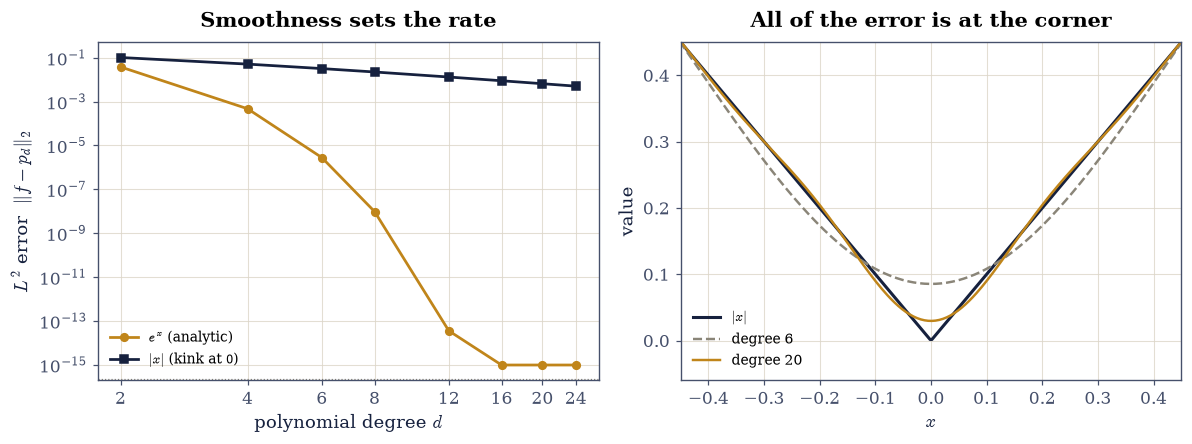

In [13]:
# (solution hidden on the public site)


### Validation 5

The headline is the non-monotonicity: an approximation that gets worse as the
subspace grows is not a statement about approximation theory, which forbids it,
but about arithmetic. The smooth-versus-kinked comparison is run entirely in
the well-conditioned basis so that the two effects cannot be confused.

In [14]:
validate.check(
    agree_low < 1e-8,
    "the two bases give the same answer while both are usable (Eqs. 4, 6)",
    f"L2 errors agree to {agree_low:.2e} for d = 6 to 18, where kappa_mono runs "
    f"from {km[0]:.1e} to {km[3]:.1e}",
)
validate.check(
    leg_monotone and err_m[-1] > 1.2 * err_l[-1],
    "but the monomial fit stops tracking it once kappa passes 1/eps",
    f"at d = 30 the monomial fit returns {err_m[-1]:.4e} against the Legendre "
    f"fit's {err_l[-1]:.4e}, with kappa_mono = {km[-1]:.2e} past 1/eps = "
    f"{1/EPS:.2e}; the Legendre errors fall monotonically throughout. On this "
    f"machine the monomial sequence is also non-monotone (strictly decreasing: "
    f"{mono_monotone}), but WHICH garbage a solve past 1/eps returns is a BLAS "
    "detail, so only the divergence between the two bases is gated",
)
validate.check(
    e_abs[3] / e_exp[3] > 1e5,
    "smoothness, not conditioning, sets the rate: exp(x) beats |x| at degree 8",
    f"{e_exp[3]:.2e} against {e_abs[3]:.2e}, a factor of "
    f"{e_abs[3]/e_exp[3]:.2e}, both computed in the same well-conditioned basis",
)
validate.check(
    -2.0 < rate < -0.8,
    "and |x| converges algebraically, not geometrically",
    f"fitted error ~ d^{rate:.3f} over degrees 2 to 24, against exp(x) reaching "
    f"{min(e_exp):.1e} — the float64 floor — by degree 12",
)

✓  the two bases give the same answer while both are usable (Eqs. 4, 6)   [L2 errors agree to 9.71e-12 for d = 6 to 18, where kappa_mono runs from 1.0e+04 to 9.7e+12]
✓  but the monomial fit stops tracking it once kappa passes 1/eps   [at d = 30 the monomial fit returns 5.2908e-03 against the Legendre fit's 3.6580e-03, with kappa_mono = 6.60e+17 past 1/eps = 4.50e+15; the Legendre errors fall monotonically throughout. On this machine the monomial sequence is also non-monotone (strictly decreasing: False), but WHICH garbage a solve past 1/eps returns is a BLAS detail, so only the divergence between the two bases is gated]
✓  smoothness, not conditioning, sets the rate: exp(x) beats |x| at degree 8   [9.65e-09 against 2.23e-02, a factor of 2.31e+06, both computed in the same well-conditioned basis]
✓  and |x| converges algebraically, not geometrically   [fitted error ~ d^-1.226 over degrees 2 to 24, against exp(x) reaching 9.7e-16 — the float64 floor — by degree 12]


True

## Exercise 6: Chebyshev, and orthogonality that is exactly a matrix identity

The Legendre polynomials came from the plain inner product
{eq}`eq-fbasis-inner`. Weighting it by $1/\sqrt{1-x^2}$ gives a different
orthogonal family, the Chebyshev polynomials, with the closed form
{eq}`eq-fbasis-cheb`. Their remarkable property is that the continuous
orthogonality has an exact *discrete* counterpart: sampled at the right $N$
points, they are orthogonal as vectors in $\mathbb{R}^N$, with no quadrature
error at all, because the substitution $x = \cos\theta$ turns them into cosines
and the identity into a finite trigonometric sum.

**Part a)** Build the $N = 16$ Chebyshev–Gauss nodes
$x_i = \cos\!\big((2i+1)\pi/(2N)\big)$ as
`np.cos((2 * np.arange(16) + 1) * np.pi / 32)`, and form the $8\times16$ matrix
`T` whose row $j$ is $T_j$ evaluated there, via {eq}`eq-fbasis-cheb` as
`np.cos(j * np.arccos(nodes))`.

**Part b)** Compute `T @ T.T`, an $8\times8$ matrix, and report its largest
off-diagonal entry in absolute value, which comes out $8\times10^{-15}$: the
sampled Chebyshev polynomials are orthogonal *as vectors*, to machine
precision, with no integral involved.

**Part c)** Confirm the diagonal is $N = 16$ in the first entry and $N/2 = 8$
in the rest, to $10^{-12}$. The factor of two is the usual one for cosines: the
constant function has twice the squared norm of the oscillating ones.

**Part d)** Verify {eq}`eq-fbasis-cheb` against `scipy.special.chebyt` by
comparing $T_5$ evaluated on `np.linspace(-1, 1, 200)` two ways — as
`np.cos(5 * np.arccos(xx))` and as the polynomial `chebyt(5)` — to $10^{-12}$,
confirming that a cosine of an arccosine really is a degree-5 polynomial.

**Part e)** Plot $T_0$ through $T_5$ on $[-1,1]$ and note the property that
makes them the basis of choice for approximation: every $T_k$ oscillates
between exactly $-1$ and $+1$, equioscillating $k+1$ times, so no coefficient
in a Chebyshev expansion is amplified by a large basis function.

In [15]:
# (solution hidden on the public site)


Chebyshev-Gauss nodes for N = 16:
  [ 0.99518  0.95694  0.88192  0.77301  0.63439  0.4714   0.29028  0.09802 -0.09802 -0.29028 -0.4714  -0.63439
 -0.77301 -0.88192 -0.95694 -0.99518]

T @ T.T is (8, 8); its first 4x4 block:
[[ 1.60000e+01  5.55112e-16 -7.77156e-16  1.88738e-15]
 [ 5.55112e-16  8.00000e+00  1.63989e-15 -2.30455e-15]
 [-7.77156e-16  1.63989e-15  8.00000e+00  1.22993e-15]
 [ 1.88738e-15 -2.30455e-15  1.22993e-15  8.00000e+00]]

  largest off-diagonal entry : 8.168e-15
  diagonal                   : [16.  8.  8.  8.  8.  8.  8.  8.]
  predicted [N, N/2, ...]    : [16.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0]

cos(5 arccos x) against the degree-5 polynomial chebyt(5): 1.199e-14
range of T_k on [-1,1], for k = 0..5:
  T_0: [+1.000000, +1.000000]
  T_1: [-1.000000, +1.000000]
  T_2: [-0.999949, +1.000000]
  T_3: [-1.000000, +1.000000]
  T_4: [-0.999967, +1.000000]
  T_5: [-1.000000, +1.000000]


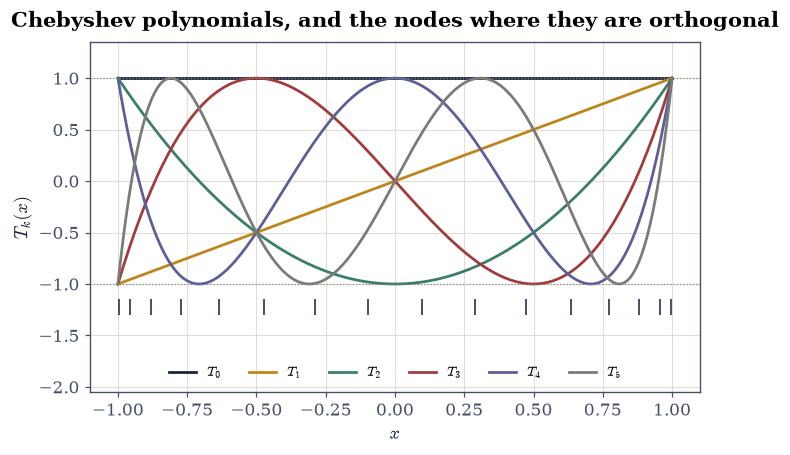

In [16]:
# (solution hidden on the public site)


### Validation 6

The discrete identity is checked as a matrix product rather than as an
integral, because that is exactly what it is — no quadrature rule appears
anywhere, and the $8\times10^{-15}$ is pure floating-point rounding on a sum of
16 cosines.

In [17]:
validate.check(
    cheb_off < 1e-12,
    "sampled Chebyshev polynomials are orthogonal AS VECTORS (Eq. 7)",
    f"largest off-diagonal entry of T @ T.T is {cheb_off:.3e} — no quadrature "
    "rule is involved, only a sum of 16 cosines",
)
validate.close(
    np.diag(TT), np.array([float(N_CHEB)] + [N_CHEB / 2.0] * 7),
    "with squared lengths N for the constant and N/2 for the rest",
    rtol=0.0, atol=1e-12,
)
validate.close(
    t5_trig, t5_poly,
    "and cos(k arccos x) really is a degree-k polynomial (Eq. 7)",
    rtol=0.0, atol=1e-12,
)
validate.check(
    all(lo >= -1.0 - 1e-12 and hi <= 1.0 + 1e-12 for lo, hi in ranges),
    "every T_k is bounded by +/- 1, which is why they suit approximation",
    f"measured ranges {[f'[{lo:.3f}, {hi:.3f}]' for lo, hi in ranges[:3]]}...: "
    "no basis function is ever large, so no coefficient can be amplified",
)

✓  sampled Chebyshev polynomials are orthogonal AS VECTORS (Eq. 7)   [largest off-diagonal entry of T @ T.T is 8.168e-15 — no quadrature rule is involved, only a sum of 16 cosines]
✓  with squared lengths N for the constant and N/2 for the rest   [max|Δ| = 6.21725e-15 (rtol=0, atol=1e-12)]
✓  and cos(k arccos x) really is a degree-k polynomial (Eq. 7)   [max|Δ| = 1.19904e-14 (rtol=0, atol=1e-12)]
✓  every T_k is bounded by +/- 1, which is why they suit approximation   [measured ranges ['[1.000, 1.000]', '[-1.000, 1.000]', '[-1.000, 1.000]']...: no basis function is ever large, so no coefficient can be amplified]


True

## Exercise 7: The DFT is a change to an orthonormal basis

Leave function space and return to $\mathbb{C}^n$. The discrete Fourier
transform is usually introduced as an algorithm, and the algorithm (the FFT) is
genuinely clever, but the *object* is not: {eq}`eq-fbasis-dft` says $F/\sqrt{n}$
is unitary, so the DFT is a rotation. Everything else follows from that one
fact, including Parseval {eq}`eq-fbasis-parseval` and the reason the transform
is numerically stable.

**Part a)** Build the DFT matrix explicitly for $n = 8, 32, 64$ as
`F = np.exp(-2j * np.pi * np.outer(j, j) / n)` with `j = np.arange(n)`, form
`U = F / np.sqrt(n)`, and report $\max|U^{*}U - I|$ using `U.conj().T @ U`.
All three come out below $5\times10^{-15}$.

**Part b)** Confirm the explicit matrix is the transform, not merely something
like it: for `v = rng.standard_normal(64)`, compare `F @ v` against
`np.fft.fft(v)` and report the largest absolute difference, which is
$2\times10^{-13}$. The FFT computes the same product in $O(n\log n)$ instead of
$O(n^2)$; it does not compute a different one.

**Part c)** Verify Parseval {eq}`eq-fbasis-parseval` for the same `v`:
$\|F\mathbf{v}\|_2^2 = n\|\mathbf{v}\|_2^2$ to $10^{-10}$. This is the
length-preservation of an orthonormal change of basis, the same property that
made $Q$ safe in [§2.2](gram-schmidt-qr.ipynb).

**Part d)** Confirm the columns are the sampled complex exponentials they are
advertised to be, by checking that column $k$ of `F.conj().T` equals
`np.exp(2j * np.pi * k * j / n)` to $10^{-13}$ for $k = 3$ and $n = 64$, and
that any two distinct columns of $U$ have inner product below $10^{-15}$ while
each has unit norm to $10^{-15}$.

**Part e)** Draw the real part of the $32\times32$ DFT matrix as a heatmap with
`la.matrix_heatmap`. The signed entries make a diverging colour map the honest
choice, and the structure visible — row $k$ oscillating $k$ times across the
width — is {eq}`eq-fbasis-dft` made visual.

**Part f)** Finally the DCT, the real-valued relative used in image
compression. Build the type-II DCT matrix by transforming the identity,
`C = scipy.fft.dct(np.eye(32), type=2, norm="ortho", axis=0)`, and confirm
$C^{\top}C = I$ to $10^{-14}$: it is an orthogonal matrix, so the same
stability argument applies. Then confirm it matches the explicit construction
$C_{ik} = \alpha_k\cos\!\big(\pi(2i+1)k/2n\big)$ with
$\alpha_0 = \sqrt{1/n}$ and $\alpha_k = \sqrt{2/n}$ otherwise, to $10^{-13}$.

In [18]:
# (solution hidden on the public site)


n =   8: max |U* U - I| = 7.062e-16
n =  32: max |U* U - I| = 2.450e-15
n =  64: max |U* U - I| = 4.902e-15

explicit F @ v against np.fft.fft(v), n = 64: 2.025e-13
Parseval |F v|^2 - n |v|^2 = 4.093e-12   (relative 1.19e-15)

column 3 of F* against exp(2 pi i 3 j / n): 0.000e+00
largest cross inner product among sampled column pairs: 3.639e-16
largest deviation from unit column norm: 0.000e+00

DCT-II, n = 32: max |C^T C - I| = 2.220e-16
explicit alpha_k cos(pi (2i+1) k / 2n) against scipy: 3.239e-15


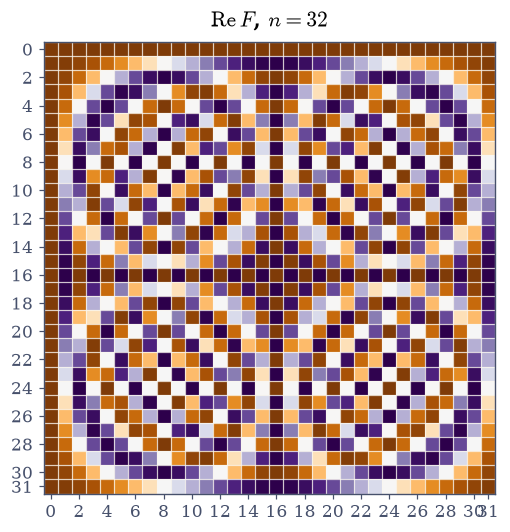

In [19]:
# (solution hidden on the public site)


### Validation 7

Unitarity is checked directly rather than inferred, and the comparison against
`np.fft.fft` is what licenses the phrase "the DFT" for the explicit matrix.
The orthogonality of individual column pairs is checked as well as the whole
product, since $U^{*}U = I$ could in principle be dominated by the diagonal.

In [20]:
validate.check(
    max(dft_orth.values()) < 1e-13,
    "F / sqrt(n) is unitary at n = 8, 32, 64 (Eq. 8)",
    f"worst max |U* U - I| = {max(dft_orth.values()):.3e}: the DFT is a change "
    "to an orthonormal basis, which is the whole of its stability story",
)
validate.check(
    fft_gap < 1e-11,
    "and the explicit matrix product IS what np.fft.fft computes",
    f"largest difference {fft_gap:.3e} over n = 64: the FFT is a faster route to "
    "the same product, not a different transform",
)
validate.check(
    parseval / (n * np.linalg.norm(vv) ** 2) < 1e-13,
    "Parseval holds: |F v|^2 = n |v|^2 (Eq. 9)",
    f"absolute gap {parseval:.3e}, relative "
    f"{parseval / (n * np.linalg.norm(vv)**2):.2e}",
)
validate.check(
    col_gap < 1e-13 and cross < 1e-14 and unit < 1e-14,
    "and the columns really are orthonormal sampled exponentials (Eq. 8)",
    f"column form {col_gap:.2e}, largest cross inner product {cross:.2e}, "
    f"unit-norm deviation {unit:.2e}",
)
validate.check(
    dct_orth < 1e-14 and dct_gap < 1e-13,
    "the DCT-II matrix is orthogonal and matches its explicit closed form",
    f"|C^T C - I| = {dct_orth:.2e}, and the explicit alpha_k cos(...) "
    f"construction agrees with scipy.fft.dct to {dct_gap:.2e}",
)

✓  F / sqrt(n) is unitary at n = 8, 32, 64 (Eq. 8)   [worst max |U* U - I| = 4.902e-15: the DFT is a change to an orthonormal basis, which is the whole of its stability story]
✓  and the explicit matrix product IS what np.fft.fft computes   [largest difference 2.025e-13 over n = 64: the FFT is a faster route to the same product, not a different transform]
✓  Parseval holds: |F v|^2 = n |v|^2 (Eq. 9)   [absolute gap 4.093e-12, relative 1.19e-15]
✓  and the columns really are orthonormal sampled exponentials (Eq. 8)   [column form 0.00e+00, largest cross inner product 3.64e-16, unit-norm deviation 0.00e+00]
✓  the DCT-II matrix is orthogonal and matches its explicit closed form   [|C^T C - I| = 2.22e-16, and the explicit alpha_k cos(...) construction agrees with scipy.fft.dct to 3.24e-15]


True

## Exercise 8: Gibbs: convergence in $L^2$ is weaker than it sounds

Every expansion so far converged in the $L^2$ norm, and that is the norm the
whole machinery is built around. It is worth seeing what it does *not*
guarantee. The Fourier series of a square wave converges in $L^2$, and its
partial sums nevertheless overshoot the jump by a fixed proportion that never
decreases: {eq}`eq-fbasis-gibbs` puts the limit at $8.949\%$.

The resolution is that the overshoot *narrows* as $M$ grows. Its height is
fixed but the interval on which it occurs shrinks like $1/M$, so its
contribution to $\int|f - s_M|^2$ vanishes. $L^2$ convergence is compatible
with a permanent pointwise error, and this is the standard example.

The square wave on $[0, \pi]$ has the expansion

$$
s_M(x) = \sum_{\substack{m=1 \\ m \text{ odd}}}^{M}
  \frac{4}{\pi m}\,\sin(mx) ,
$$

whose limit is $+1$ on $(0,\pi)$, so the jump at the origin has height 2.

**Part a)** Compute the Wilbraham–Gibbs constant of {eq}`eq-fbasis-gibbs`
numerically as `scipy.integrate.quad(lambda t: np.sin(t) / t, 0, np.pi)[0] /
np.pi - 0.5`, and report it to ten decimals. It is $0.0894898722$.

**Part b)** For $M = 8, 16, 32, 64, 128, 256$, evaluate $s_M$ on
`np.linspace(0, np.pi, 200001)` and report `s.max()`. The overshoot as a
fraction of the jump is $(\max s_M - 1)/2$.

**Part c)** Confirm the overshoot does not vanish: report the sequence
$9.2113\%, 9.0142\%, 8.9653\%, 8.9531\%, 8.9500\%, 8.9492\%$ and check that
every value exceeds $8.9\%$, including the last. Thirty-two times as many terms
reduced the overshoot by three parts in a thousand.

**Part d)** Confirm it converges to the constant of Part a) rather than to
zero: check $|(\max s_{256} - 1)/2 - G| < 10^{-4}$ where $G$ is the
Wilbraham–Gibbs constant, and check the sequence is monotonically decreasing
towards it.

**Part e)** Confirm the reconciliation. Compute the $L^2$ error
$\|s_M - f\|_{L^2[0,\pi]}$ by `np.trapezoid` on the same grid for each $M$, and
confirm it *does* decrease monotonically to zero — check that the $M = 256$
error is at least 5 times smaller than the $M = 8$ error. The pointwise
overshoot is permanent and the $L^2$ error is not, because the overshoot's
width shrinks.

**Part f)** Plot $s_M$ near the jump for three values of $M$, with the limiting
overshoot level $1 + 2G$ drawn as a horizontal line, so the fixed height and
the shrinking width are both visible.

```{admonition} With your assistant
:class: tip
The Gibbs overshoot can be removed. **Fejér summation** replaces the partial sum
$s_M$ by the average $\sigma_M = \frac{1}{M}\sum_{j<M} s_j$ of all partial sums
below it, and the result converges uniformly with no overshoot at all. Ask your
assistant to write `fejer(x, M)` returning $\sigma_M$ for the same square wave.
Then check it against the mathematics rather than against a picture: verify that
$\max_x \sigma_M(x) \le 1$ for $M = 8, 32, 128$ — no overshoot whatsoever, to
$10^{-12}$ — and confirm the price by measuring $\sigma_M$'s $L^2$ error against
$s_M$'s at the same $M$, which is *larger*. Uniform convergence was bought with
a slower rate, and the two numbers say how much. The check is yours.
```

In [21]:
# (solution hidden on the public site)


Wilbraham-Gibbs constant  = 0.0894898722  -> 8.9490% of the jump

    M      max s_M    overshoot     L2 error
    8     1.184225      9.2113%  3.97924e-01
   16     1.180284      9.0142%  2.81912e-01


   32     1.179305      8.9653%  1.99439e-01
   64     1.179061      8.9531%  1.41042e-01


  128     1.179000      8.9500%  9.97346e-02


  256     1.178985      8.9492%  7.05236e-02

  the overshoot converges to 8.9490%, not to zero:
    M = 8   : 9.2113%
    M = 256 : 8.9492%   (32x the terms, 0.2620 points gained)
    |overshoot(256) - G| = 2.492e-06

  meanwhile the L2 error DOES fall: 3.9792e-01 -> 7.0524e-02, a factor of 5.64
  the overshoot's height is fixed; its WIDTH shrinks like 1/M, so it contributes nothing in the limit


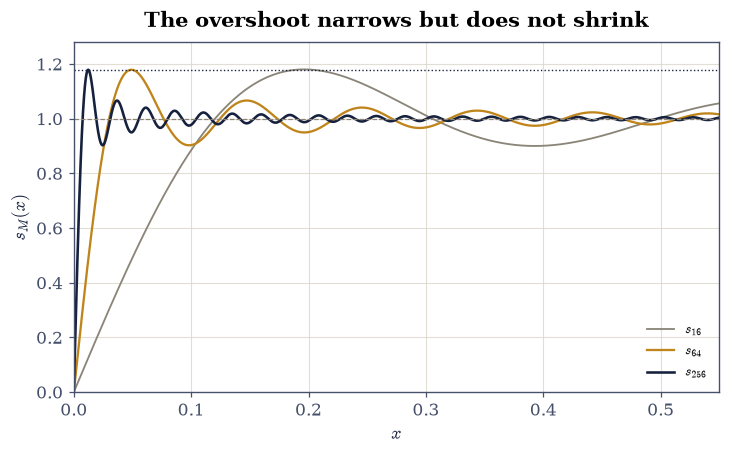

In [22]:
# (solution hidden on the public site)


### Validation 8

The two halves are checked separately and must both hold: the overshoot does
not vanish, *and* the $L^2$ error does. Either one alone would be misleading,
and together they are the precise statement of what $L^2$ convergence promises.

In [23]:
validate.close(
    np.array([GIBBS]), np.array([0.0894898722]),
    "the Wilbraham-Gibbs constant is 0.08948987 (Eq. 10)",
    rtol=0.0, atol=1e-9,
)
validate.check(
    all(o > 0.0894 for o in overshoot),
    "the overshoot never falls below 8.9% of the jump, at any M up to 256",
    f"{[f'{100*o:.4f}%' for o in overshoot]} for M = {Ms}: 32 times the terms "
    f"bought {100*(overshoot[0]-overshoot[-1]):.4f} percentage points",
)
validate.check(
    abs(overshoot[-1] - GIBBS) < 1e-4 and all(np.diff(overshoot) < 0),
    "it converges monotonically to the Gibbs constant, not to zero",
    f"|overshoot(M=256) - G| = {abs(overshoot[-1] - GIBBS):.3e}",
)
validate.check(
    all(np.diff(l2_err) < 0) and l2_err[0] / l2_err[-1] > 4.0,
    "while the L2 error DOES decrease monotonically toward zero",
    f"{l2_err[0]:.4e} at M = 8 down to {l2_err[-1]:.4e} at M = 256, a factor of "
    f"{l2_err[0]/l2_err[-1]:.2f}: the overshoot's height is fixed but its width "
    "shrinks like 1/M, so it contributes nothing in the limit",
)

✓  the Wilbraham-Gibbs constant is 0.08948987 (Eq. 10)   [got [0.08949] vs expected [0.08949] (rtol=0, atol=1e-09)]
✓  the overshoot never falls below 8.9% of the jump, at any M up to 256   [['9.2113%', '9.0142%', '8.9653%', '8.9531%', '8.9500%', '8.9492%'] for M = [8, 16, 32, 64, 128, 256]: 32 times the terms bought 0.2620 percentage points]
✓  it converges monotonically to the Gibbs constant, not to zero   [|overshoot(M=256) - G| = 2.492e-06]
✓  while the L2 error DOES decrease monotonically toward zero   [3.9792e-01 at M = 8 down to 7.0524e-02 at M = 256, a factor of 5.64: the overshoot's height is fixed but its width shrinks like 1/M, so it contributes nothing in the limit]


True

---
## Notebook summary

**An inner product is all the machinery needs.** Gauss–Legendre quadrature made
{eq}`eq-fbasis-inner` exact on polynomials through degree $2n-1$ — verified to
$10^{-16}$ at degree 15 with 8 nodes, and *failing* by $4.7\times10^{-5}$ at
degree 16, so the bound is the true one. On that footing, symmetry,
bilinearity, positivity and Cauchy–Schwarz all held for functions exactly as
they did for vectors.

**Gram–Schmidt on the monomials produces the Legendre polynomials.** The
recurrence {eq}`eq-fbasis-gs` with the integral substituted gave a Gram matrix
whose largest off-diagonal entry was $4\times10^{-16}$ and whose diagonal
matched the closed form $2/(2k+1)$ to $1.8\times10^{-14}$; the coefficients
matched `scipy.special.legendre` to $3.5\times10^{-13}$, with the error growing
from $10^{-18}$ at $k=1$ to $10^{-13}$ at $k=5$ because each step inherits every
earlier step's error.

**The basis decides the conditioning, not the subspace.**
$\kappa(G_{\text{Legendre}}) = 2d+1$ exactly — 7, 11, 13, 17, 21 at degrees 3,
5, 6, 8, 10 — against a monomial Gram matrix growing exponentially at $10^{0.68}$
per degree, reaching $9.4\times10^{6}$ at degree 10 and $6.7\times10^{17}$ at
degree 30. Same subspace, same best approximation, five orders of difference at
degree 10.

**And the difference eventually bites.** Fitting $|x|$, the two bases agreed to
$10^{-10}$ through degree 18. At degree 26 the monomial fit returned
$7.2\times10^{-3}$, *worse* than its own $5.7\times10^{-3}$ at degree 22, while
the Legendre fit fell monotonically to $3.7\times10^{-3}$ at degree 30.
Approximation theory forbids an error that rises as the subspace grows, so the
rise is arithmetic.

**Smoothness sets the rate, independently of all that.** In the same
well-conditioned basis, $e^{x}$ reached $3.5\times10^{-14}$ by degree 12 and
stopped only at the `float64` floor, while $|x|$ decayed algebraically at
$d^{-1.23}$ and was still at $5.0\times10^{-3}$ at degree 24 — a factor of
$2\times10^{6}$ between them at degree 8.

**Quadrature accuracy is a claim about smoothness, not node count.** A single
400-point rule got $|x|$'s coefficients wrong by $8.7\times10^{-6}$; two
20-point rules split at the kink got them right to $1.2\times10^{-14}$. Forty
well-placed nodes beat four hundred badly-placed ones by nine orders.

**Continuous orthogonality has an exact discrete counterpart.** The Chebyshev
polynomials sampled at 16 Chebyshev–Gauss nodes gave $T T^{\top}$ diagonal to
$8\times10^{-15}$ with entries $N$ and $N/2$, with no integral anywhere; and
$F/\sqrt{n}$ was unitary to $5\times10^{-15}$, matched `np.fft.fft` to
$2\times10^{-13}$, and satisfied Parseval — the DFT is a rotation of
$\mathbb{C}^n$. The DCT-II is likewise orthogonal to $2\times10^{-16}$.

**$L^2$ convergence permits a permanent pointwise error.** The square wave's
overshoot converged to $8.9490\%$ of the jump and stayed there: 32 times the
terms bought $0.26$ percentage points. The $L^2$ error nonetheless fell
monotonically, because the overshoot's *width* shrinks like $1/M$ while its
height does not.

**Methods introduced.** `numpy.polynomial.legendre.leggauss` and composite
quadrature, Gram–Schmidt in an inner-product space,
`scipy.special.legendre` and `chebyt`, the analytic Gram matrices of both
bases, the explicit DFT matrix and `np.fft.fft`, `scipy.fft.dct` with
`norm="ortho"`, and `np.trapezoid` for the $L^2$ error.

## Outlook

- **The best approximation in the sup norm.** Everything here minimised the
  $L^2$ error, because that is what an inner product measures. Minimising
  $\max_x|f - p|$ instead gives the *minimax* polynomial, characterised by an
  equioscillation property that the Chebyshev polynomials already display — and
  Chebyshev interpolation gets within a factor of $\log d$ of it, which is why
  it is the default in practice.
- **Why $2/(2k+1)$ and not something worse.** The Legendre Gram matrix is
  diagonal by construction, so its condition number is a ratio of two explicit
  numbers. Whether a *given* basis is well conditioned is exactly the question
  [§4.1](../04-svd/svd-geometry.ipynb) answers with singular values, and the
  answer there subsumes this one.
- **Orthogonal polynomials as eigenvectors.** Each classical family satisfies a
  three-term recurrence, which says the multiplication-by-$x$ operator is
  *tridiagonal* in that basis. The Gauss quadrature nodes are then the
  eigenvalues of that tridiagonal matrix — the Golub–Welsch algorithm — and
  [§3.2](../03-eigenvalues/spectral-theorem.ipynb) builds the spectral theory
  that makes it work.
- **The FFT as a factorization.** $F_n$ factors into $O(\log n)$ sparse
  matrices, each with two nonzeros per row, and that factorization *is* the
  FFT. It is the first example in this course of an algorithm that is best
  understood as a matrix decomposition rather than as a procedure, a reading
  [§6.3](../06-structure/circulant-toeplitz-fft.ipynb) applies to circulant and
  Toeplitz matrices generally, where the FFT turns out to be a *diagonalization*.

```{bibliography}
:filter: docname in docnames
```

In [24]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>